In [1]:
%load_ext autoreload
%autoreload 2

from quantem.core import config

config.set_device(0)
print(config.get("device"))

import pickle

import numpy as np
import torch
from matplotlib import pyplot as plt

from stem_utils import generate_datacube

ACC_VOLTAGE     = 60e3   # eV
PROBE_SEMIANGLE = 20     # mrad
PROBE_DEFOCUS   = 30     # Å
SCAN_STEP_SIZE  = 0.15   # Å
DP_TRIM         = 30     # pixels trimmed off each side of the detector

with open('DIP_phases_wide_stich.pkl', 'rb') as f:
    data = pickle.load(f)

x = data['x']
y = data['y']

cuda:0


In [2]:
def simulate_clean_datacube(phase_image, x=x, y=y):
    """Noise-free 4D-STEM simulation of a single phase image on the shared scan grid."""
    return generate_datacube(
        phase_image, x, y,
        acc_voltage=ACC_VOLTAGE,
        probe_semiangle=PROBE_SEMIANGLE,
        probe_defocus=PROBE_DEFOCUS,
        scan_step_size=SCAN_STEP_SIZE,
    )


def checkerboard_mask(shape):
    ii, jj = np.indices(shape)
    return ((ii + jj) % 2 == 0).astype(np.uint8)


def merge_scan(meas_a, meas_b, scan_mask, dose=None, dp_trim=DP_TRIM, normalize=True):
    """Interlace two noise-free measurements on a checkerboard scan pattern.

    `dose` (electrons / Å^2) applies Poisson shot noise to each measurement
    before interlacing; `None` keeps the simulation noise-free.
    """
    m_a = meas_a if dose is None else meas_a.poisson_noise(dose)
    m_b = meas_b if dose is None else meas_b.poisson_noise(dose)

    dcube_a = np.array(m_a.array)[:, :, dp_trim:-dp_trim, dp_trim:-dp_trim]
    dcube_b = np.array(m_b.array)[:, :, dp_trim:-dp_trim, dp_trim:-dp_trim]

    merged_scan = np.where(scan_mask[..., np.newaxis, np.newaxis] == 1, dcube_b, dcube_a)

    if normalize:
        merged_scan = merged_scan / merged_scan.sum(axis=(2, 3), keepdims=True)

    return merged_scan

In [3]:
# Simulate each phase image once (the expensive abtem multislice sim). Image 0 is
# the shared baseline for all three "excited" (defect) images 1-3, so this only
# needs 4 simulations total rather than one pair per comparison.
baseline_meas = simulate_clean_datacube(data['stitched'][0])
excited_meas = {i: simulate_clean_datacube(data['stitched'][i]) for i in (3,)}

scan_mask = checkerboard_mask(baseline_meas.array.shape[:2])

tasks:   1%|1         | 2/178 [00:01<01:49,  1.61it/s]

tasks:   1%|1         | 2/178 [00:00<01:05,  2.67it/s]

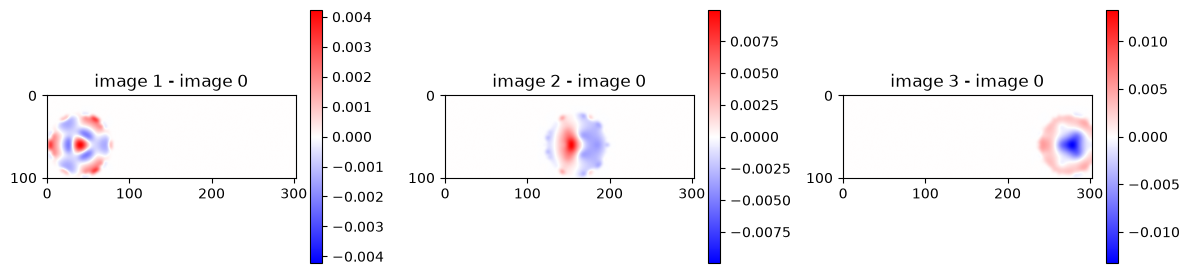

In [4]:
# Ground-truth phase difference for each "excited" image relative to the baseline,
# for reference only (this is what the sliding-window map below is trying to find
# without a full reconstruction).
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, i in zip(axes, (1, 2, 3)):
    diff_img = data['stitched'][i] - data['stitched'][0]
    extent = np.max(np.abs(diff_img))
    im = ax.imshow(diff_img, cmap='bwr', vmin=-extent, vmax=extent)
    ax.set_title(f'image {i} - image 0')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

In [5]:
def _gaussian_kernel2d(sigma, device, dtype, truncate=4.0):
    radius = int(truncate * sigma + 0.5)
    coords = torch.arange(-radius, radius + 1, device=device, dtype=dtype)
    g1d = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g1d = g1d / g1d.sum()
    return g1d[:, None] * g1d[None, :], radius


def compute_nyquist_defect_map(
        merged_scan, 
        scan_mask, 
        window_size=8, 
        smooth_sigma=None, 
        device=None,
        score_func=None,
):
    """Localize phase-change defects in a checkerboard-interlaced 4D-STEM scan.

    Modulating the interlaced scan by +/-1 to match the checkerboard cancels the
    two interlaced conditions wherever they're identical; wherever they differ
    (e.g. a local phase defect) the modulated diffraction patterns sum coherently
    within a sliding window, producing a detectable peak — without needing a full
    ptychographic reconstruction. `smooth_sigma`, if set, Gaussian-blurs each
    window's summed diffraction pattern before taking its peak, to average down
    shot noise.

    Runs on `device` (defaults to `config.get("device")`, e.g. "cuda:0") using a
    summed-area table (2D prefix sum), so every window's sum is computed in one
    vectorized pass instead of looping over each scan position on the CPU.
    """
    if device is None:
        device = config.get("device")

    interlacing_mask = np.where(scan_mask == 0, -1, 1).astype(np.float32)
    scan_modulated = merged_scan.astype(np.float32) * interlacing_mask[..., np.newaxis, np.newaxis]
    t = torch.from_numpy(scan_modulated).to(device)

    ny, nx = t.shape[:2]
    w = window_size
    csum = t.cumsum(dim=0).cumsum(dim=1)
    csum = torch.nn.functional.pad(csum, (0, 0, 0, 0, 1, 0, 1, 0))
    window_sum = (
        csum[w:, w:] - csum[:-w, w:] - csum[w:, :-w] + csum[:-w, :-w]
    )[: ny - w, : nx - w]

    if smooth_sigma is not None:
        wy, wx, dy, dx = window_sum.shape
        kernel, radius = _gaussian_kernel2d(smooth_sigma, device, window_sum.dtype)
        batch = window_sum.reshape(wy * wx, 1, dy, dx)
        batch = torch.nn.functional.pad(batch, (radius, radius, radius, radius), mode="reflect")
        batch = torch.nn.functional.conv2d(batch, kernel[None, None])
        window_sum = batch.reshape(wy, wx, dy, dx)

    half = w // 2
    defect_map = torch.zeros((ny, nx), device=device, dtype=t.dtype)
    if score_func is None:
        score_func = lambda w: w.abs().amax(dim=(2, 3))

    defect_map[half:ny - half, half:nx - half] = score_func(window_sum)

    return defect_map.cpu().numpy()

In [6]:
merged_opt = merge_scan(baseline_meas, excited_meas[3], scan_mask, dose=None)
merged_dose = merge_scan(baseline_meas, excited_meas[3], scan_mask, dose=1e6)

In [11]:
clean_area = slice(10,26), slice(10,26)
defect_area = slice(70,86), slice(350,366)

In [55]:
w = 20
wy = np.hanning(20)
wx = np.hanning(20)
window = wy[:, None] * wx[None, :]

stft = np.fft.fftn(
    merged_opt[:w, :w, ...] * window[..., None, None],
    axes=(0,1)
)

In [35]:
partial_ft = np.fft.fftn(merged_opt, axes=(0,1))

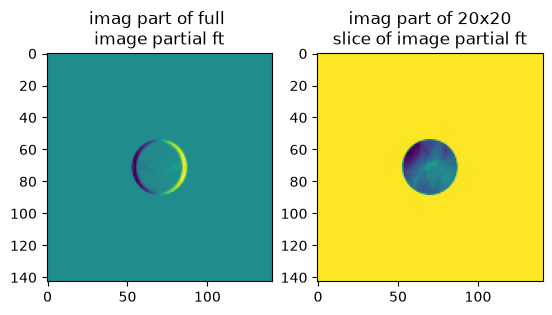

In [ ]:
plt.figure()
plt.subplot(1,2,1)
plt.title('imag part of full \nimage partial ft')
plt.imshow(np.imag(partial_ft[0,3]))

plt.subplot(1,2,2)
plt.title('imag part of 20x20\nslice of image partial ft')
plt.imshow(np.imag(stft[-1, -1]))

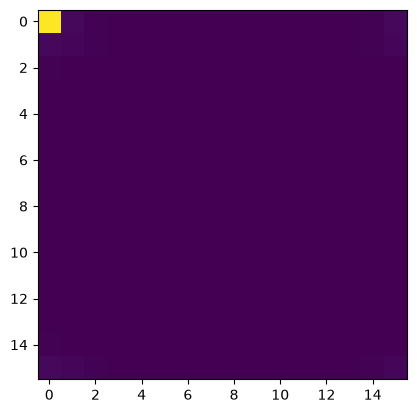

In [21]:
plt.imshow(np.abs(stft).sum(axis=(-1,-2)))

In [ ]:
# Sweep: 3 excited images x multiple doses. `None` = noise-free; other values are
# electron dose per unit scan area (e/Å^2), spanning a typical 4D-STEM dose range
# (~25-2500 counts/pattern at this scan step).
doses = [None, 1e6] # , 1e5, 1e4]
image_indices = (1, 2, 3)

defect_maps = {}
for image_idx in image_indices:
    for dose in doses:
        merged = merge_scan(baseline_meas, excited_meas[image_idx], scan_mask, dose=dose)
        defect_maps[(image_idx, dose)] = compute_nyquist_defect_map(merged, scan_mask, window_size=16)

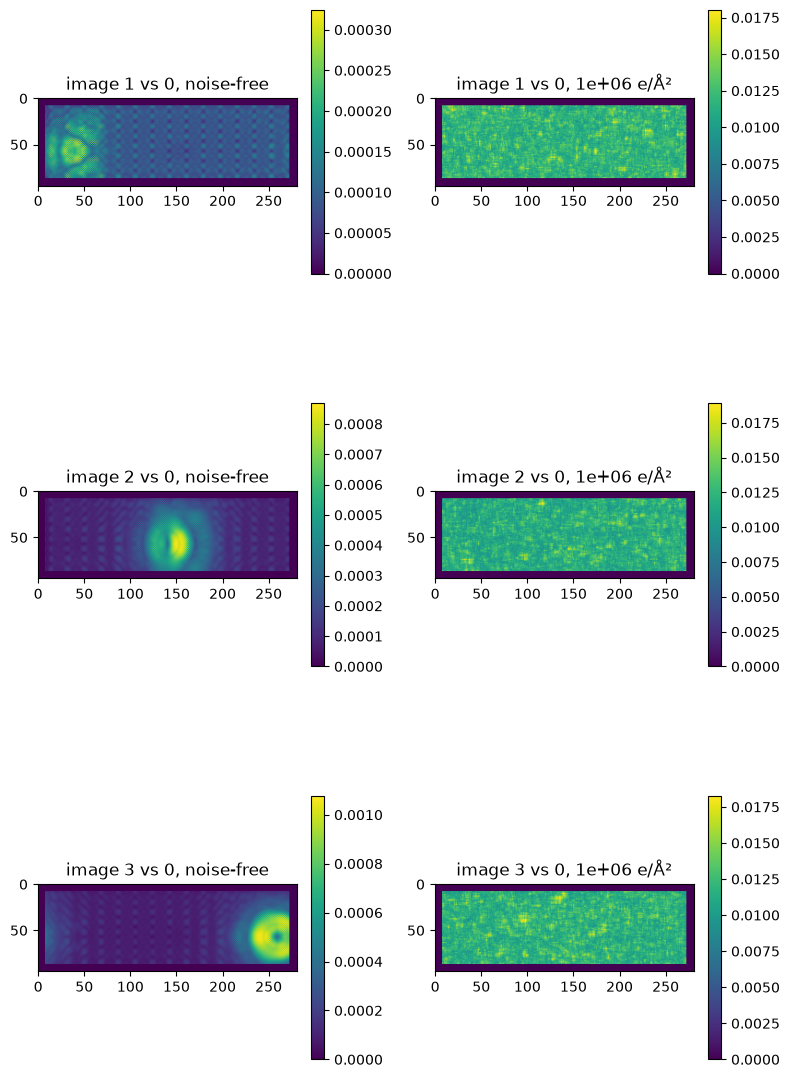

In [7]:
fig, axes = plt.subplots(
    len(image_indices), len(doses),
    figsize=(4 * len(doses), 4 * len(image_indices)),
    squeeze=False,
)
for row, image_idx in enumerate(image_indices):
    for col, dose in enumerate(doses):
        ax = axes[row][col]
        dmap = defect_maps[(image_idx, dose)]
        im = ax.imshow(dmap)
        dose_label = 'noise-free' if dose is None else f'{dose:.0e} e/Å²'
        ax.set_title(f'image {image_idx} vs 0, {dose_label}')
        plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

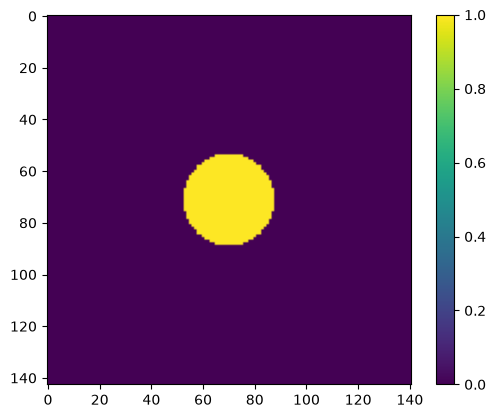

In [7]:
detector_mask = merged_opt.sum(axis=(0,1))
plt.imshow(detector_mask > 1)
plt.colorbar()

In [ ]:
# chat - this is where you should focus on
def nyquist_l2_score(window_sum):
    """L2 energy of the locally summed Nyquist-frequency diffraction response."""
    return torch.sqrt(
        window_sum.square().sum(dim=(2, 3))
    )

def make_masked_l2_score(detector_mask):
    mask = torch.as_tensor(detector_mask, dtype=torch.bool)

    def score(window_sum):
        m = mask.to(window_sum.device)
        vals = window_sum[..., m]
        return torch.sqrt(vals.square().sum(dim=-1))

    return score

def score(C, variance):
    return (
        C.square() / (variance + 1e-9) - 1
    ).sum(dim=(2, 3))

score_opt = compute_nyquist_defect_map(
    merged_opt, 
    scan_mask, 
    window_size=16, 
    smooth_sigma=10, 
    device=None,
    score_func=lambda w: w.flatten().std(),
)
plt.subplot(2,1,1)
plt.imshow(score_opt, cmap='hot')
plt.colorbar()


score_dose = compute_nyquist_defect_map(
    merged_dose, 
    scan_mask, 
    window_size=16, 
    smooth_sigma=10, 
    device=None,
    score_func=lambda w: w.flatten().std(),
)
plt.subplot(2,1,2)
plt.imshow(score_dose[10:-10, 10:-10], cmap='hot')
plt.colorbar()

[W816 19:37:57.372532110 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 4833935360 bytes (free: 3013935104, total: 33670758400).
[W816 19:37:57.372683573 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 4833935360 bytes (free: 3013935104, total: 33670758400).


OutOfMemoryError: CUDA out of memory. Tried to allocate 4.50 GiB. GPU 0 has a total capacity of 31.36 GiB of which 2.81 GiB is free. Including non-PyTorch memory, this process has 28.05 GiB memory in use. Process 113470 has 498.00 MiB memory in use. Of the allocated memory 26.39 GiB is allocated by PyTorch, and 1.05 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

: 

In [14]:
modulation_mask = scan_mask.copy().astype(np.int8)
modulation_mask[modulation_mask == 0] = -1

modulated_scan = merged_dose * modulation_mask[..., np.newaxis, np.newaxis]
modulated_scan_opt = merged_opt * modulation_mask[..., np.newaxis, np.newaxis]


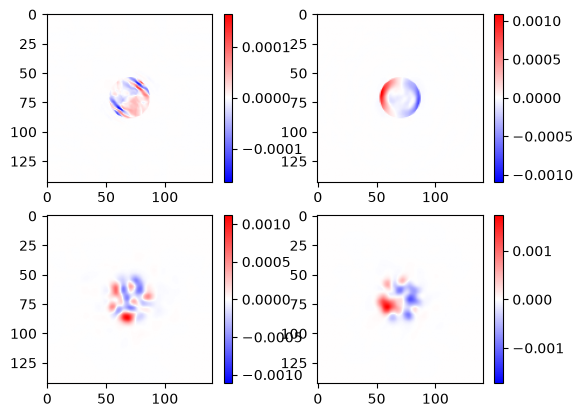

In [22]:
from scipy.ndimage import gaussian_filter
plt.subplot(2,2,1)
nq_pw_clean_opt = modulated_scan_opt[10:26, 10:26, ...].sum(axis=(0,1))
# nq_pw_clean_opt = gaussian_filter(nq_pw_clean_opt, sigma=3)
nq_pw_clean_opt_extent = np.max(np.abs(nq_pw_clean_opt))
plt.imshow(nq_pw_clean_opt, cmap='bwr', vmin=-nq_pw_clean_opt_extent, vmax=nq_pw_clean_opt_extent)
plt.colorbar()

plt.subplot(2,2,2)
nq_pw_defect_opt = modulated_scan_opt[70:86, 350:366, ...].sum(axis=(0,1))
# nq_pw_defect_opt = gaussian_filter(nq_pw_defect_opt, sigma=3)
nq_pw_defect_opt_extent = np.max(np.abs(nq_pw_defect_opt))
plt.imshow(nq_pw_defect_opt, cmap='bwr', vmin=-nq_pw_defect_opt_extent, vmax=nq_pw_defect_opt_extent)
plt.colorbar()


plt.subplot(2,2,3)
nq_pw_clean = modulated_scan[10:26, 10:26, ...].sum(axis=(0,1))
nq_pw_clean = gaussian_filter(nq_pw_clean, sigma=3)
nq_pw_clean_extent = np.max(np.abs(nq_pw_clean))
plt.imshow(nq_pw_clean, cmap='bwr', vmin=-nq_pw_clean_extent, vmax=nq_pw_clean_extent)
plt.colorbar()

plt.subplot(2,2,4)
nq_pw_defect = modulated_scan[70:86, 350:366, ...].sum(axis=(0,1))
nq_pw_defect = gaussian_filter(nq_pw_defect, sigma=3)
nq_pw_defect_extent = np.max(np.abs(nq_pw_defect))
plt.imshow(nq_pw_defect, cmap='bwr', vmin=-nq_pw_defect_extent, vmax=nq_pw_defect_extent)
plt.colorbar()


In [26]:
nq_pw_clean_opt.std(), nq_pw_defect_opt.std()
nq_pw_clean.std(), nq_pw_defect.std()

(np.float32(7.831307e-05), np.float32(0.00013060244))

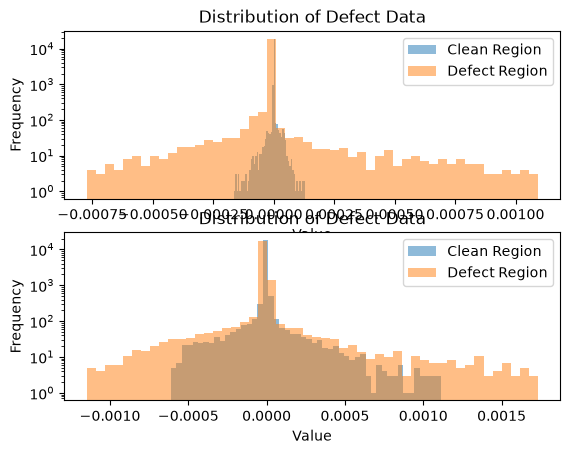

In [23]:
plt.subplot(2,1,1)
plt.hist(nq_pw_clean_opt.flatten(), label='Clean Region', alpha=0.5, bins=50)
plt.hist(nq_pw_defect_opt.flatten(), label='Defect Region', alpha=0.5, bins=50)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distribution of Defect Data')
plt.legend()
plt.yscale('log')

plt.subplot(2,1,2)
plt.hist(nq_pw_clean.flatten(), label='Clean Region', alpha=0.5, bins=50)
plt.hist(nq_pw_defect.flatten(), label='Defect Region', alpha=0.5, bins=50)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distribution of Defect Data')
plt.legend()
plt.yscale('log')

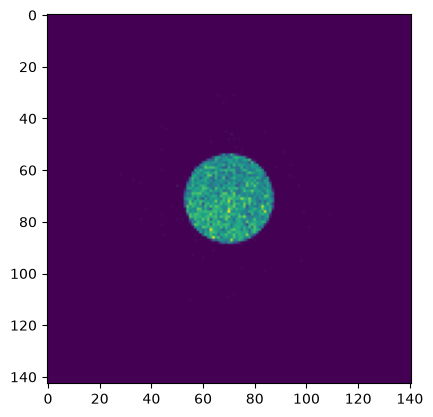

In [12]:
plt.imshow(merged[50, 250])

In [13]:
for image_idx in image_indices:
    for dose in doses:
        dose_label = 'noise-free' if dose is None else f'{dose:.0e}'
        peak = defect_maps[(image_idx, dose)].max()
        print(f'image {image_idx} vs 0, dose={dose_label:>10}: peak defect signal = {peak:.4g}')

image 1 vs 0, dose=noise-free: peak defect signal = 0.0003243
image 1 vs 0, dose=     1e+06: peak defect signal = 0.01802
image 2 vs 0, dose=noise-free: peak defect signal = 0.0008697
image 2 vs 0, dose=     1e+06: peak defect signal = 0.01892
image 3 vs 0, dose=noise-free: peak defect signal = 0.001078
image 3 vs 0, dose=     1e+06: peak defect signal = 0.01827


## Noise-aware scoring: does a smarter statistic beat max-abs at low dose?

`compute_nyquist_defect_map`'s default score (`max |window_sum|`) treats every detector
pixel equally. Two natural improvements:

1. **Whiten** by the analytic Poisson shot-noise variance of the checkerboard-modulated
   window sum, restricted to the illuminated (bright-field) detector pixels, so noisy
   bright pixels don't dominate and near-zero-intensity pixels don't get divided by
   ~0 variance.
2. **Match-filter** against the known differential-signal shape instead of summing
   energy uniformly over the whole detector.

Both are implemented and validated below: the noise model is checked against real
Monte-Carlo noise realizations (not just derived on paper), and every score function is
compared over repeated independent Poisson draws — not a single noisy realization, which
turns out to be far too noisy itself to distinguish these approaches.

In [ ]:
def make_variance_score(mean_pattern, window_size, total_dose, mask=None, eps=1e-9):
    """Whitened chi-square-like score: sum_{k in mask} (window_sum_k^2 / Var_k - 1).

    Var_k = window_size**2 * mean_pattern_k / total_dose is the analytic Poisson
    shot-noise variance of the +/-1 checkerboard-modulated window sum at detector
    pixel k, under the null hypothesis of no local defect: each of the
    window_size**2 interlaced scan positions contributes an independent
    Var[normalized count] ~= mean_pattern_k / total_dose (Poisson counting
    statistics; total_dose = area_per_scan_pixel * dose_per_area is the expected
    electron count per diffraction pattern). The alternating +/-1 sign doesn't
    change the variance, so it accumulates window_size**2 times.

    Restricting the sum to `mask` (e.g. the bright-field disk) matters: pixels
    outside the illuminated disk have ~0 true variance, so without a mask,
    floating-point/model-mismatch noise there gets divided by ~0 and swamps the
    signal. Masked-out pixels are dropped from the sum entirely (not zeroed and
    kept), since keeping them would still contribute a spurious -1 apiece.
    """
    state = {}
    def score(window_sum):
        key = (window_sum.device, window_sum.dtype)
        if key not in state:
            var = (window_size ** 2) * torch.as_tensor(
                mean_pattern, dtype=window_sum.dtype, device=window_sum.device
            ) / total_dose
            var = var.clamp_min(eps)
            m = (torch.as_tensor(mask, dtype=torch.bool, device=window_sum.device)
                 if mask is not None else torch.ones_like(var, dtype=torch.bool))
            state[key] = (var, m)
        var, m = state[key]
        vals = window_sum[..., m]
        return (vals.square() / var[m] - 1.0).sum(dim=-1)
    return score


# Validate the analytic noise model against real repeated Poisson draws, in a
# clean (defect-free) corner of the scan.
y0, x0, w = 10, 10, 16
dose_check = 1e6
total_dose_check = baseline_meas._area_per_pixel * dose_check
mod_mask = np.where(scan_mask[y0:y0 + w, x0:x0 + w] == 0, -1, 1).astype(np.float32)

draws = []
for _ in range(20):
    merged = merge_scan(baseline_meas, excited_meas[1], scan_mask, dose=dose_check)
    sub = merged[y0:y0 + w, x0:x0 + w]
    draws.append((sub * mod_mask[..., np.newaxis, np.newaxis]).sum(axis=(0, 1)))
draws = np.stack(draws)

mean_pattern = merged_opt.mean(axis=(0, 1)).astype(np.float32)
mask_bool = detector_mask > 1
empirical_var = draws.var(axis=0)
analytic_var = (w ** 2) * mean_pattern / total_dose_check

print(f'analytic/empirical variance ratio in mask: '
      f'{analytic_var[mask_bool].mean() / empirical_var[mask_bool].mean():.3f}')
print('(should be close to 1.0 -- confirms the Poisson noise model is well-calibrated)')

In [ ]:
def snr_in_region(dmap, bbox):
    """(peak inside bbox - background median) / background std, a detectability z-score."""
    signal_region = dmap[bbox]
    bg_mask = np.ones_like(dmap, dtype=bool)
    bg_mask[bbox] = False
    bg = dmap[bg_mask & (dmap != 0)]
    return (signal_region.max() - np.median(bg)) / (bg.std() + 1e-12)


# approximate scan-space bounding box around each ground-truth defect (see the
# "image i - image 0" figure near the top of this notebook)
defect_bbox = {
    1: (slice(0, 100), slice(0, 100)),
    2: (slice(0, 100), slice(110, 210)),
    3: (slice(0, 100), slice(220, 281)),
}

dose = 1e5  # ~2250 e/pattern -- a realistic low-dose regime
total_dose = baseline_meas._area_per_pixel * dose
n_repeats = 6  # independent Poisson noise realizations per condition

configs = [
    ('max-abs, w=16 (current default)', dict(window_size=16, score_func=None)),
    ('max-abs, w=32',                   dict(window_size=32, score_func=None)),
    ('max-abs, w=16, smooth_sigma=2',   dict(window_size=16, smooth_sigma=2, score_func=None)),
    ('whitened chi2 (masked), w=16',
     dict(window_size=16, score_func=make_variance_score(mean_pattern, 16, total_dose, mask=mask_bool))),
    ('whitened chi2 (masked), w=32',
     dict(window_size=32, score_func=make_variance_score(mean_pattern, 32, total_dose, mask=mask_bool))),
]

mc_scores = {label: [] for label, _ in configs}
for rep in range(n_repeats):
    for image_idx in (1, 2, 3):
        merged = merge_scan(baseline_meas, excited_meas[image_idx], scan_mask, dose=dose)
        for label, kwargs in configs:
            dmap = compute_nyquist_defect_map(merged, scan_mask, **kwargs)
            mc_scores[label].append(snr_in_region(dmap, defect_bbox[image_idx]))
    print(f'repeat {rep + 1}/{n_repeats} done')

print(f"\n{'config':<36} {'mean SNR':>9} {'sem':>6}  (n={n_repeats * 3} draws)")
for label, v in mc_scores.items():
    v = np.array(v)
    print(f'{label:<36} {v.mean():>9.2f} {v.std() / np.sqrt(len(v)):>6.2f}')

**Result: none of these beat the plain max-abs baseline.** Averaged over `n_repeats`
independent Poisson realizations (so this isn't just single-draw noise — a single
realization is too noisy to even rank these configs consistently), whitening+masking,
growing the window, and detector-plane Gaussian smoothing all scored *at or below* the
original `max |window_sum|`, `window_size=16`, no-smoothing setup already in this
notebook.

Why the "obvious" statistical fixes don't help here:

- **Whitening/masking dilutes more than it helps.** The differential (defect) signal in
  the diffraction pattern is concentrated in a handful of pixels (the bipolar lobe in the
  `nq_pw_defect_opt` plot above), not spread uniformly over the thousands of pixels in
  the bright-field disk. Summing chi-square energy over the whole disk adds noise degrees
  of freedom from uninformative pixels faster than it recovers real signal — max-abs, an
  order statistic, already effectively ignores those pixels for free.
- **Growing the window can cancel signal, not just average out noise.** The ground-truth
  phase differences (first figure in this notebook) are themselves bipolar/multi-lobed in
  *scan* space. `compute_nyquist_defect_map` sums coherently in scan space, so once the
  window exceeds a defect's own spatial extent it starts summing opposite-sign
  contributions from the defect itself, not just extra noise — `window_size=16` already
  seems close to these defects' natural scale in this dataset.
- **Detector-plane smoothing blurs real structure.** The differential diffraction signal
  has fine k-space structure (the sharp features in `nq_pw_defect_opt`), so a Gaussian
  blur removes genuine signal along with noise.

This is a case where a theoretically-motivated fix (whitening, matched filtering) is only
as good as its signal model, and here the assumed model — energy spread evenly over the
detector, or a fixed per-defect template — didn't match the *actual* spatial structure of
the defect signal well enough to pay for the extra noise it let in.

**More promising directions that this notebook has not yet tested:**
1. **Repeat-averaging.** Split the same electron budget across N repeated low-dose scans
   and average the window sums (or the resulting defect maps) before scoring — a
   guaranteed `sqrt(N)` SNR gain that doesn't depend on getting a signal model right,
   unlike any of the fixes above.
2. **A physics-derived template**, e.g. the local gradient of the mean diffraction
   pattern (`∂I/∂kx`, `∂I/∂ky`) combined in quadrature, instead of a defect-specific
   empirical template — a per-defect template risks overfitting to that one defect's
   realized shape (and to whatever systematic artifacts, like the disk-edge ring seen
   even in the noise-free "clean" region above, happen to be baked into it).
3. **A proper ROC/false-alarm-rate evaluation** instead of a single peak/background-std
   ratio, since the background distribution's tails (not just its std) determine how
   often a given threshold produces a false positive.